In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from xgboost import XGBClassifier
import joblib


In [2]:
train_df = pd.read_csv("D:/final dkd/train data.csv")
test_df = pd.read_csv("D:/final dkd/test data.csv")

# Create safe copies
train = train_df.copy()
test = test_df.copy()


In [3]:
train

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [4]:
test

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


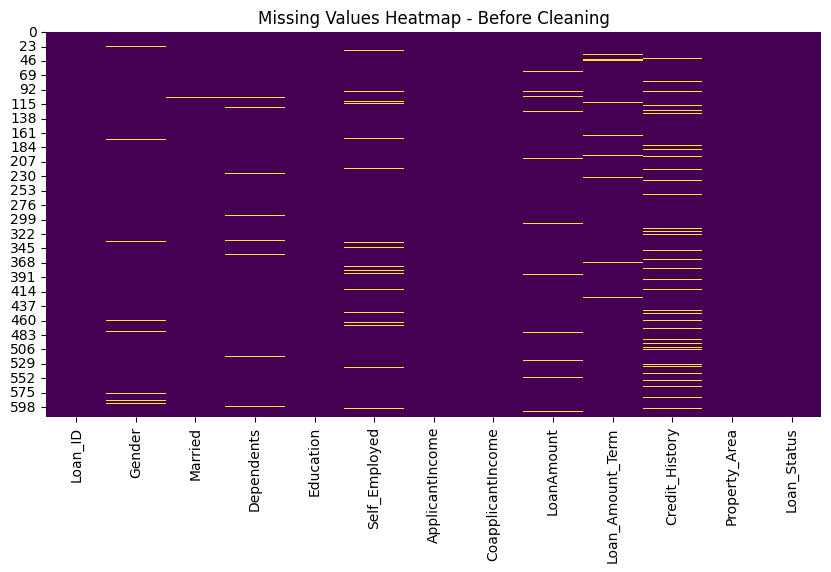

In [5]:
plt.figure(figsize=(10,5))
sns.heatmap(train.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap - Before Cleaning")
plt.show()


In [6]:
for col in train.columns:
    if col == "Loan_Status":
        continue

    if train[col].dtype == "object":
        train[col] = train[col].fillna(train[col].mode()[0])
    else:
        train[col] = train[col].fillna(train[col].median())


In [7]:
for col in test.columns:
    if col in train.columns:
        if train[col].dtype == "object":
            test[col] = test[col].fillna(train[col].mode()[0])
        else:
            test[col] = test[col].fillna(train[col].median())


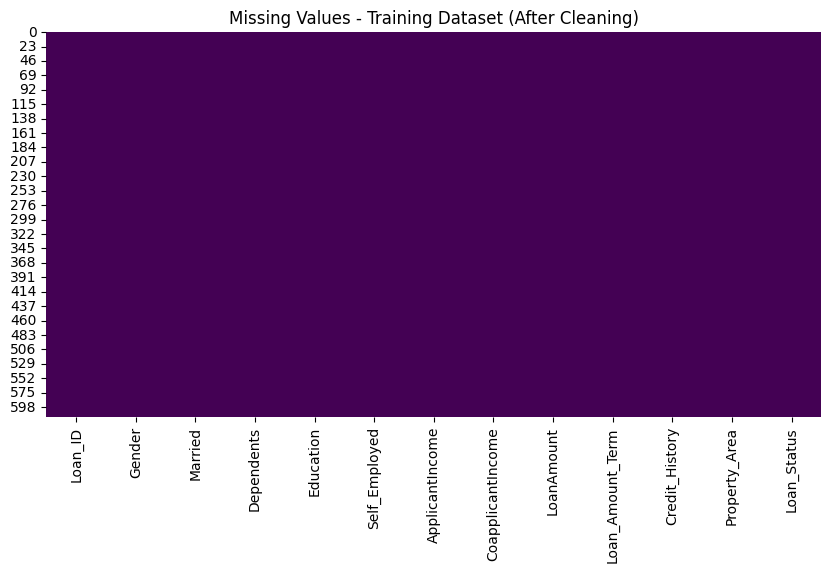

In [8]:
plt.figure(figsize=(10,5))
sns.heatmap(train.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values - Training Dataset (After Cleaning)")
plt.show()


In [9]:
if 'Loan_ID' in train.columns:
    train.drop('Loan_ID', axis=1, inplace=True)

if 'Loan_ID' in test.columns:
    test.drop('Loan_ID', axis=1, inplace=True)


In [11]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in train.columns:
    if train[col].dtype == "object":
        le = LabelEncoder()
        train[col] = le.fit_transform(train[col])
        label_encoders[col] = le

        if col in test.columns:
            test[col] = le.transform(test[col])


In [12]:
train.dtypes
test.dtypes


Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome      int64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
dtype: object

In [13]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = train.drop("Loan_Status", axis=1)
y = train["Loan_Status"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,        # 20% for testing
    random_state=42,
    stratify=y            # VERY IMPORTANT for imbalanced data
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)



X_train shape: (491, 11)
X_test shape: (123, 11)
y_train shape: (491,)
y_test shape: (123,)


In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy='auto',
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [15]:
print(y_train_smote.value_counts())


Loan_Status
1    337
0    337
Name: count, dtype: int64


In [16]:
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    min_child_weight=1,
    gamma=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=1,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

In [17]:
xgb_model.fit(X_train_smote, y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [18]:
y_pred_xgb = xgb_model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8211382113821138
Confusion Matrix:
 [[26 12]
 [10 75]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.68      0.70        38
           1       0.86      0.88      0.87        85

    accuracy                           0.82       123
   macro avg       0.79      0.78      0.79       123
weighted avg       0.82      0.82      0.82       123



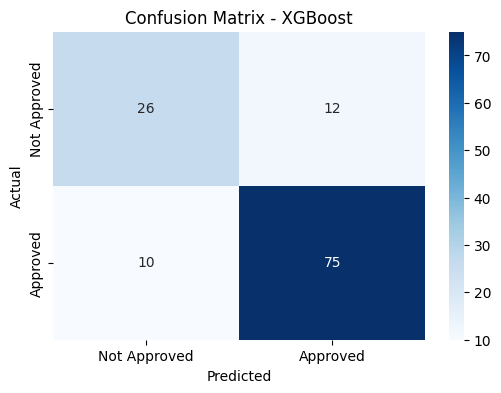

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Approved', 'Approved'],
    yticklabels=['Not Approved', 'Approved']
)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


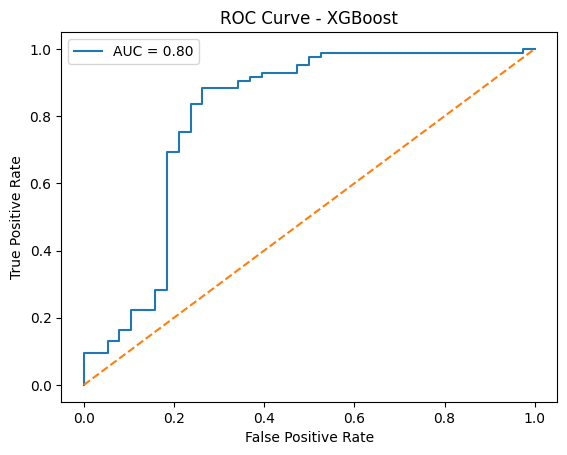

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = xgb_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

<Figure size 800x600 with 0 Axes>

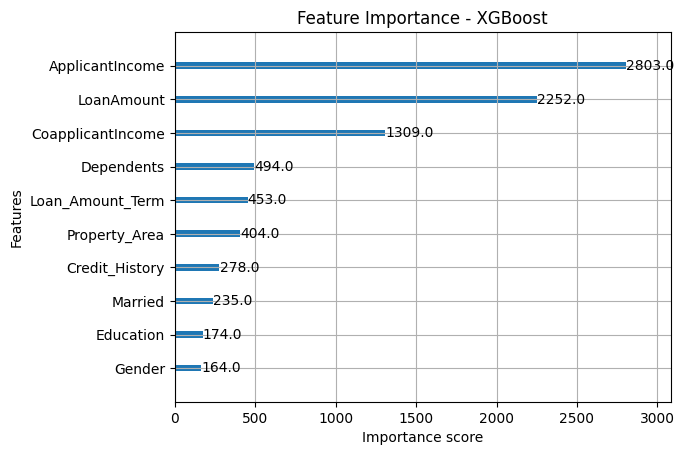

In [22]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(8,6))
plot_importance(xgb_model, max_num_features=10)
plt.title("Feature Importance - XGBoost")
plt.show()


In [23]:
# 1️⃣ Save the trained XGBoost model
joblib.dump(xgb_model, "loan_approval_model.pkl")
print("Model saved as 'loan_approval_model.pkl'")

# 2️⃣ Save the feature columns used for training
model_columns = X_train.columns.tolist()
joblib.dump(model_columns, "model_columns.pkl")
print("Model columns saved as 'model_columns.pkl'")

# 3️⃣ Save the LabelEncoders for categorical columns
joblib.dump(label_encoders, "label_encoders.pkl")
print("Label encoders saved as 'label_encoders.pkl'")

Model saved as 'loan_approval_model.pkl'
Model columns saved as 'model_columns.pkl'
Label encoders saved as 'label_encoders.pkl'
